<a href="https://colab.research.google.com/github/Optimus0205/ProcDna-Case-Study/blob/main/Ques_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas openpyxl -q

import pandas as pd

# In Colab, uncomment the next 2 lines to upload the file interactively:
# from google.colab import files
# files.upload()   # select PrimeRx_Datasets.xlsx

PATH = "PrimeRx Datasets.xlsx"   # update path if using Drive instead
OUR_DRUG = "DRG001"

alerts = pd.read_excel(PATH, sheet_name="Alerts")
sales = pd.read_excel(PATH, sheet_name="Sales")
affil = pd.read_excel(PATH, sheet_name="Affiliation")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

print("Alerts:", alerts.shape)
print("Sales:", sales.shape)
print("Affiliation:", affil.shape)
alerts.head()

Alerts: (9537, 4)
Sales: (5917, 6)
Affiliation: (216, 3)


,Alert_ID,Alert_Date,HCP_ID,Lab_Result
0,ALT001134,2024-03-07,HCP009,Negative
1,ALT008550,2024-10-15,HCP109,Negative
2,ALT008560,2023-07-01,HCP110,Positive
3,ALT006177,2023-12-04,HCP045,Negative
4,ALT008377,2023-07-01,HCP105,Positive


In [ ]:
alerts_with_acc = alerts.merge(affil, on="HCP_ID", how="inner")
acc_alert_counts = alerts_with_acc.groupby("Account_ID").size().reset_index(name="Total_Alerts")
top10_accounts = acc_alert_counts.sort_values("Total_Alerts", ascending=False).head(10)

our_drug_sales = sales[sales["Drug_ID"] == OUR_DRUG]
sales_with_acc = our_drug_sales.merge(affil, on="HCP_ID", how="inner")
acc_rx_count = sales_with_acc.groupby("Account_ID").size().reset_index(name="Our_Drug_Prescription_Count")

q4 = top10_accounts.merge(acc_rx_count, on="Account_ID", how="left")
q4["Our_Drug_Prescription_Count"] = q4["Our_Drug_Prescription_Count"].fillna(0).astype(int)
q4["Conversion_Ratio"] = (q4["Our_Drug_Prescription_Count"] / q4["Total_Alerts"]).round(3)

q4 = q4.sort_values("Conversion_Ratio", ascending=True).reset_index(drop=True)
q4.index += 1
print("Top 10 accounts by alert volume, ranked by LOWEST conversion ratio")
display(q4)

Top 10 accounts by alert volume, ranked by LOWEST conversion ratio


,Account_ID,Total_Alerts,Our_Drug_Prescription_Count,Conversion_Ratio
1,ACC001,3296,385,0.117
2,ACC003,1195,159,0.133
3,ACC002,2350,373,0.159
4,ACC004,530,164,0.309
5,ACC005,585,275,0.470
6,ACC006,493,298,0.604
7,ACC012,85,57,0.671
8,ACC009,100,77,0.770
9,ACC007,114,209,1.833
10,ACC010,92,295,3.207


In [ ]:
affiliated_doctors = affil.groupby("Account_ID")["HCP_ID"].nunique().reset_index(name="Num_Affiliated_Doctors")

our_drug_by_hcp = our_drug_sales.groupby("HCP_ID")["Prescription_Volume"].sum().reset_index(name="HCP_Volume")
our_drug_by_hcp_acc = our_drug_by_hcp.merge(affil, on="HCP_ID", how="inner")

active_doctors = (
    our_drug_by_hcp_acc[our_drug_by_hcp_acc["HCP_Volume"] > 0]
    .groupby("Account_ID")["HCP_ID"].nunique().reset_index(name="Num_Active_Doctors")
)
acc_volume = our_drug_by_hcp_acc.groupby("Account_ID")["HCP_Volume"].sum().reset_index(name="Our_Drug_Prescription_Volume")

q5 = affiliated_doctors.merge(active_doctors, on="Account_ID", how="left")
q5 = q5.merge(acc_volume, on="Account_ID", how="left")
q5["Num_Active_Doctors"] = q5["Num_Active_Doctors"].fillna(0).astype(int)
q5["Our_Drug_Prescription_Volume"] = q5["Our_Drug_Prescription_Volume"].fillna(0).astype(int)

q5["Prescription_Volume_per_Active_Doctor"] = q5.apply(
    lambda r: (r["Our_Drug_Prescription_Volume"] / r["Num_Active_Doctors"]) if r["Num_Active_Doctors"] > 0 else 0,
    axis=1
).round(2)

q5=q5[q5['Prescription_Volume_per_Active_Doctor']>0]
q5.reset_index(drop=True, inplace=True)
q5.index += 1

q5_top10 = q5.sort_values("Prescription_Volume_per_Active_Doctor", ascending=True).head(11).reset_index(drop=True)
q5_top10=q5_top10[q5_top10['Prescription_Volume_per_Active_Doctor']>0]
print("Top 10 accounts by LOWEST prescriptions-per-active-doctor ratio")
display(q5_top10)

Top 10 accounts by LOWEST prescriptions-per-active-doctor ratio


,Account_ID,Num_Affiliated_Doctors,Num_Active_Doctors,Our_Drug_Prescription_Volume,Prescription_Volume_per_Active_Doctor
0,ACC017,3,1,59,59.00
1,ACC015,8,7,1347,192.43
2,ACC012,10,7,1804,257.71
3,ACC009,11,10,2699,269.90
4,ACC003,24,15,4947,329.80
5,ACC018,4,3,1095,365.00
6,ACC004,17,13,5402,415.54
7,ACC008,7,6,3049,508.17
8,ACC014,6,6,3126,521.00
9,ACC023,1,1,573,573.00


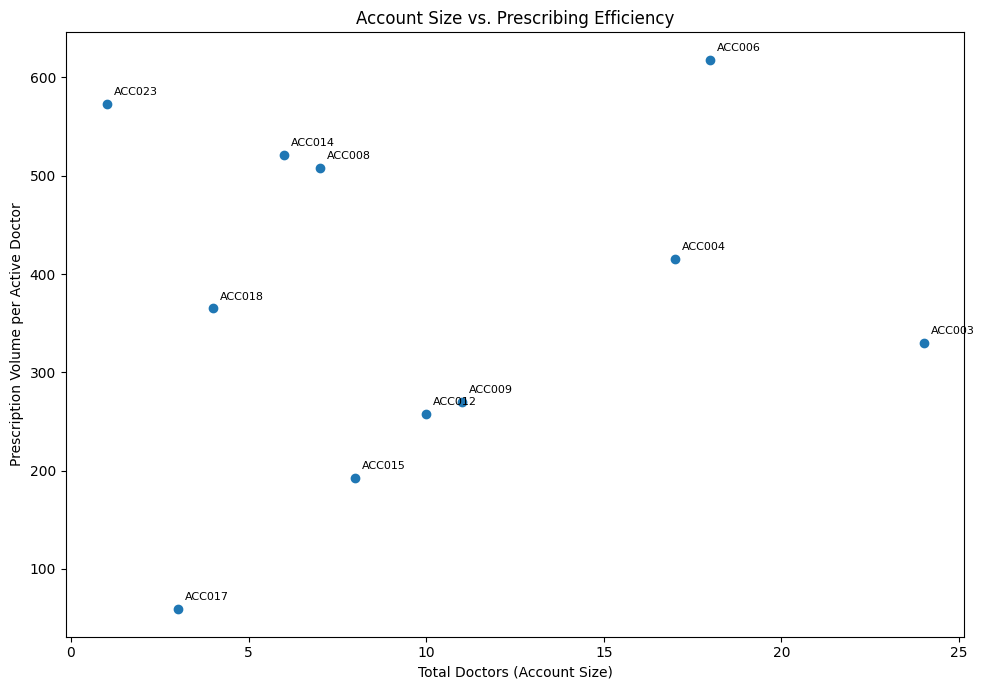

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7)) # Increased figure size for better readability of labels
plt.scatter(q5_top10["Num_Affiliated_Doctors"], q5_top10["Prescription_Volume_per_Active_Doctor"])
plt.xlabel("Total Doctors (Account Size)")
plt.ylabel("Prescription Volume per Active Doctor")
plt.title("Account Size vs. Prescribing Efficiency")

# Annotate each point with its Account_ID
for i, row in q5_top10.iterrows():
    plt.annotate(row["Account_ID"],
                 (row["Num_Affiliated_Doctors"], row["Prescription_Volume_per_Active_Doctor"]),
                 textcoords="offset points", # Offset the text from the data point
                 xytext=(5,5), # Offset by 5 points in x and y direction
                 ha='left', # Horizontal alignment
                 va='bottom', # Vertical alignment
                 fontsize=8) # Font size for the labels

plt.tight_layout()
plt.show()